<a href="https://colab.research.google.com/github/sumpumm/ML_MODELS_FROM_SCRATCH/blob/main/Polynomial_Regression/polynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##first applying simple linear regression

In [2]:
#real world data about CO2 emissions. The data in non linear
!wget -O FuelConsumption.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv

--2026-03-15 07:15:47--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.03s   

2026-03-15 07:15:47 (2.28 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [25]:
data=pd.read_csv("FuelConsumption.csv")
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [26]:
data.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [27]:
data=data[['FUELCONSUMPTION_COMB_MPG','CO2EMISSIONS']]

In [28]:
data.rename(columns={'FUELCONSUMPTION_COMB_MPG':'comubstion', 'CO2EMISSIONS':'emission'},inplace=True)


In [29]:
data.head()

,comubstion,emission
0,33,196
1,29,221
2,48,136
3,25,255
4,27,244


In [30]:
data.shape

(1067, 2)

In [31]:
data.ndim

2

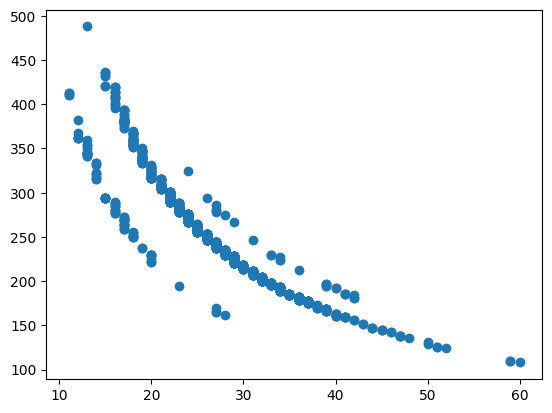

In [32]:
plt.scatter(data.comubstion,data.emission)

In [33]:
x=data.iloc[:,0:1].values
y=data.iloc[:,-1].values

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(x,y,test_size=0.2,random_state=0)

In [35]:
from sklearn.linear_model import LinearRegression

L=LinearRegression()
L.fit(X_train, Y_train)

LinearRegression()

In [36]:
Y_pred= L.predict(X_test)

In [39]:
Y_pred

array([322.37298476, 219.90243448, 243.54948455, 219.90243448,
       156.84363431, 290.84358468, 219.90243448, 275.07888463,
       212.02008446, 314.49063474, 298.7259347 , 346.02003483,
       196.25538441, 282.96123465, 172.60833435, 267.19653461,
       338.13768481, 235.66713452, 259.31418459, 322.37298476,
       196.25538441, 196.25538441, 251.43183457, 251.43183457,
        70.13778407, 282.96123465, 275.07888463, 346.02003483,
       259.31418459,  -0.80336613, 322.37298476, 251.43183457,
       306.60828472, 251.43183457, 196.25538441, 204.13773444,
       290.84358468, 235.66713452, 251.43183457, 251.43183457,
       188.37303439, 188.37303439, 212.02008446, 156.84363431,
       290.84358468, 204.13773444, 267.19653461, 180.49068437,
       361.78473487, 322.37298476, 314.49063474, 338.13768481,
       290.84358468,  70.13778407, 243.54948455, 180.49068437,
       282.96123465, 141.07893426, 267.19653461, 219.90243448,
       219.90243448, 212.02008446, 235.66713452, 346.02

In [40]:
from scipy.optimize import root
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score:", r2_score(Y_test, Y_pred))
print("RMSE:",np.sqrt(mean_squared_error(Y_test, Y_pred)))

R2 score: 0.8261445883060663
RMSE: 27.0911073218799


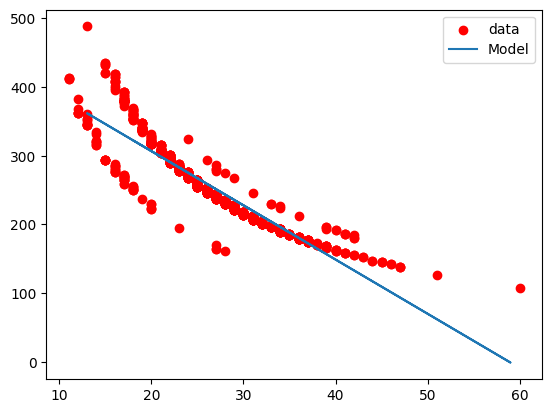

In [42]:
plt.scatter(X_train,Y_train,label="data",color="r")
plt.plot(X_test,Y_pred, label="Model")
plt.legend()
plt.show()

## polynomial regression

In [61]:
from sklearn.preprocessing import PolynomialFeatures
poly=  PolynomialFeatures(degree=5)
X_poly= poly.fit_transform(X_train)
print(X_poly.shape)
X_poly

(853, 6)


array([[1.0000000e+00, 2.2000000e+01, 4.8400000e+02, 1.0648000e+04,
        2.3425600e+05, 5.1536320e+06],
       [1.0000000e+00, 1.9000000e+01, 3.6100000e+02, 6.8590000e+03,
        1.3032100e+05, 2.4760990e+06],
       [1.0000000e+00, 2.7000000e+01, 7.2900000e+02, 1.9683000e+04,
        5.3144100e+05, 1.4348907e+07],
       ...,
       [1.0000000e+00, 2.4000000e+01, 5.7600000e+02, 1.3824000e+04,
        3.3177600e+05, 7.9626240e+06],
       [1.0000000e+00, 2.1000000e+01, 4.4100000e+02, 9.2610000e+03,
        1.9448100e+05, 4.0841010e+06],
       [1.0000000e+00, 2.5000000e+01, 6.2500000e+02, 1.5625000e+04,
        3.9062500e+05, 9.7656250e+06]])

In [62]:
L1=LinearRegression()

In [63]:
L1.fit(X_poly,Y_train)


LinearRegression()

In [64]:
X_test_poly= poly.fit_transform(X_test)

In [65]:
Y_pred_poly= L1.predict(X_test_poly)

In [66]:
print("R2 score:", r2_score(Y_test, Y_pred_poly))
print("RMSE:",np.sqrt(mean_squared_error(Y_test, Y_pred_poly)))

R2 score: 0.8951339534781982
RMSE: 21.04021132594523


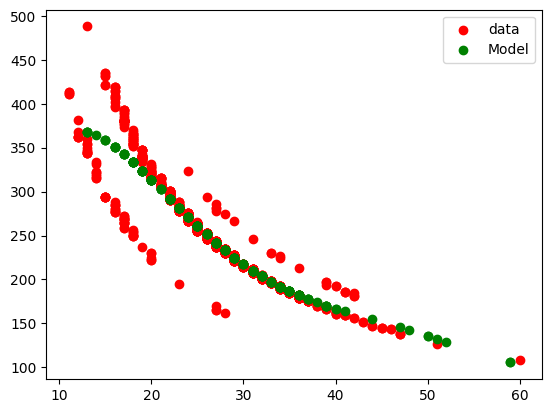

In [67]:
plt.scatter(X_train,Y_train,label="data",color="r")
plt.scatter(X_test,Y_pred_poly, label="Model",color="green")
plt.legend()
plt.show()